# AMP 2023 RA disease signatures scored on SIG26 in vitro conditions

Builds RA-vs-OA single-cell DEG signatures for three AMP CD4 subsets (T-7, T-3, T-4) and scores
them on SIG26-24h in vitro-polarized human CD4 T cells, to ask which ligand conditions reproduce
each subset's disease program.

- **Scope:** `T + F` CTAP RA biopsies plus all OA controls.
- **DE:** single-cell Wilcoxon rank-sum, RA vs OA, per subset.
- **Scoring:** ULM on SIG26 condition profiles relative to `none_none` (§7), and preranked GSEA
  on SIG26's per-condition DESeq2 statistics (§8).

## 1. Import

In [1]:
# ---- every import the notebook uses, so the dependency list is readable from the top
import os
import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
import gseapy as gp
from sklearn.preprocessing import StandardScaler
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from adjustText import adjust_text
import cnsplots as cns
cns.settings.panel_label_fontname = "sans serif"

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
sc.settings.verbosity = 1

# Repo-relative paths (inputs: imports_stable/, outputs: analysis_outs/)
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/03_activity_inference_model"

# ---- inputs
AMP_H5AD = f"{IMPORTS_DIR}/external/AMP_2023/amp_2023_cd4_processed.h5ad"
AMP_CTAP = f"{IMPORTS_DIR}/external/AMP_2023/2023_AMP2_CTAP.csv"
SIG26_PROC = f"{IMPORTS_DIR}/SIG26/processing_outs"
SIG26_DEG = f"{IMPORTS_DIR}/SIG26/analysis_outs"
SIG26_RUN = "SIG26-24h"    # the SIG26 run every score below is computed against
input_SIG26 = pd.read_csv(f"{SIG26_PROC}/norm_counts_matrix_{SIG26_RUN}.csv", index_col=0)
OUT_DIR = f"{OUTS_DIR}/inference_model_validation_AMP"

# ---- RA disease dataset parameters
T7 = "T-7: CD4+ IFNG+ Tph/Tfh"
T3 = "T-3: CD4+ IFNG- Tph/Tfh"
T4 = "T-4: CD4+ naive"
CELLTYPES = {T7: "T-7", T3: "T-3", T4: "T-4"}
ORDER = ["T-7", "T-4", "T-3"]
TF_CTAP = "T + F"          # the scope: these RA biopsies + all OA controls
CASE, CONTROL = "RA", "control"

# ---- DE and disease signature gene-set parameters
EXPR_LAYER = "log1p_norm"  # expression layer to use for DE
MIN_DETECT_FRAC = 0.1      # gene detected in >= this fraction of cells
PADJ_MAX = 0.01            # hard significance filter on the gene sets
TOP_N = 100                # cap per set, both directions pooled

# ---- gene cleanup, from 01_activity_sc_visualization.ipynb
USE_BAD_GENE_FILTER = True
BAD_GENE_PATTERN = (r"^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|"
                    r"MALAT|TRA[VJ]|TRB[VDJ]|HBA[12]|^IG[HKL]|RP[1-9]+\-|^MTRNR")

# ---- ULM and GSEA parameters
CONTROL_LABEL = "none_none"      # the unstimulated arm every condition is contrasted against
GSEA_RANK_LABEL = "DESeq2 stat"  # axis label for the ranking statistic GSEA walks down
GSEA_PERM, GSEA_MIN_SIZE, GSEA_MAX_SIZE = 10000, 10, 1000
GSEA_SEED, GSEA_THREADS = 0, 8

os.makedirs(OUT_DIR, exist_ok=True)
print(OUT_DIR)

/data1/rudenska/EYW/git_projects/SIG13/analysis_outs/inference_model_validation_AMP


## 2. Load and define the contrast

OA biopsies have no CTAP, so their `CTAP` is set to `"control"`, making them the shared control
arm. `Repeat` biopsies also have no CTAP and are removed by the scope filter; the printout reports
how many cells that drops.

In [2]:
rna = sc.read_h5ad(AMP_H5AD)
print(rna)

ctap = pd.read_csv(AMP_CTAP)
obs = rna.obs.copy()
idx = obs.index
obs = obs.reset_index(drop=True).merge(ctap, on=["subject_id", "biopsy_id"], how="left")
obs.index = idx

obs["CTAP"] = obs["CTAP"].where(obs["treatment"] != "osteoarthritis control", "control")
obs["group"] = np.where(obs["treatment"] == "osteoarthritis control", CONTROL, CASE)
obs["celltype"] = obs["cluster_name"].map(CELLTYPES)
rna.obs = obs

# no Repeat filter -- report what the CTAP scope filter does with them instead
in_ct = rna.obs["celltype"].notna()
in_scope = rna.obs["CTAP"].isin([TF_CTAP, "control"])
dropped = rna.obs.loc[in_ct & ~in_scope]
print(f"\ncells in the three subsets: {int(in_ct.sum())}")
print(f"  excluded by the CTAP scope filter: {len(dropped)}")
print(dropped.groupby(["treatment"], observed=True).size().to_string())

adata = rna[in_ct & in_scope].copy()
adata.obs["group"] = pd.Categorical(adata.obs["group"], categories=[CONTROL, CASE])
adata.obs["celltype"] = pd.Categorical(adata.obs["celltype"], categories=ORDER)
print(f"\nscoped object: {adata.n_obs} cells x {adata.n_vars} genes")

AnnData object with n_obs × n_vars = 55432 × 20657
    obs: 'sample', 'cluster_number', 'cluster_name', 'cell_type', 'subject_id', 'biopsy_id', 'treatment', 'joint', 'sex', 'age', 'CDAI', 'disease_duration', 'tissue_type', 'krenn_lining', 'krenn_inflammation', 'qc', 'das28_crp3', 'das28_esr3', 'ccp_result', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'Module 1', 'Module 2', 'Module 3', 'Module 4', 'Module 5', 'Module 6', 'Module 7', 'Module 8', 'Module 9', 'Module 10', 'Module 11', 'Module 12', 'Module 13', 'Module 14', 'Module 15', 'Module 16', 'Module 17', 'Module 18', 'Module 19', 'Module 20', 'Module 21', 'Module 22'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'varian

In [3]:
# per-arm composition: cells, biopsies (the pseudobulk unit), donors (the independence unit)
# and library complexity, which is the covariate a rank-sum test cannot carry
COMPLEXITY = next((c for c in ["n_genes_by_counts", "nFeature_RNA"]
                   if c in adata.obs.columns), None)
agg = dict(cells=("group", "size"), biopsies=("biopsy_id", "nunique"),
           donors=("subject_id", "nunique"))
if COMPLEXITY:
    agg["median_genes_per_cell"] = (COMPLEXITY, "median")
else:
    print("no library-complexity column found in obs")
comp = adata.obs.groupby(["celltype", "group"], observed=True).agg(**agg)
display(comp)

cells  biopsies  donors  median_genes_per_cell
celltype group                                                  
T-7      control    128         6       6                 1603.5
         RA         393         8       8                 2018.0
T-4      control    229         5       5                 1370.0
         RA        1915         8       8                 1606.0
T-3      control    347         5       5                 1486.0
         RA        1204         8       8                 1665.0

## 3. Gene cleanup

Bad genes (mitochondrial, ribosomal, TCR/Ig, etc.) are removed before DE, so BH correction and
the `TOP_N` cap are computed on the gene space that is reported.

In [4]:
adata.X = adata.layers[EXPR_LAYER].copy()   # rank-based test reads X directly

if USE_BAD_GENE_FILTER:
    bad = adata.var_names.str.contains(BAD_GENE_PATTERN, regex=True)
    print(f"bad-gene pattern removes {int(bad.sum())} / {adata.n_vars} genes")
    print("  examples:", ", ".join(adata.var_names[bad][:12]))
    adata = adata[:, ~bad].copy()
else:
    print("bad-gene filter OFF")
print(f"tested gene space: {adata.n_vars} genes")

bad-gene pattern removes 401 / 20657 genes
  examples: MRPL20, RPL22, RPL11, RPS6KA1, MRPS15, RPS8, MRPL37, RPL5, MTMR11, MRPS21, MRPL9, RPS27
tested gene space: 20256 genes


## 4. Single-cell Wilcoxon DE, one test per subset

`sc.tl.rank_genes_groups(method="wilcoxon", tie_correct=True)`, restricted to genes detected in at
least `MIN_DETECT_FRAC` of the subset's cells. Tie correction matters because log1p counts have a
large block of zeros. `donor_consistency` is the fraction of RA donors whose mean moves in the
logFC direction relative to the pooled control mean.

In [5]:
def donor_consistency(sub, genes):
    """Per gene, fraction of case donors whose donor mean exceeds the pooled control mean,
    signed so that a value near 1 means 'consistent with the reported direction'."""
    X = sub[:, genes].X
    X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
    df = pd.DataFrame(X, columns=genes)
    df["donor"] = sub.obs["subject_id"].to_numpy()
    df["group"] = sub.obs["group"].astype(str).to_numpy()

    ctrl_mean = df.loc[df["group"] == CONTROL, genes].mean(axis=0)
    case_donor = df.loc[df["group"] == CASE].groupby("donor")[genes].mean()
    return (case_donor > ctrl_mean).mean(axis=0)


de = {}
for celltype in ORDER:
    sub = adata[adata.obs["celltype"] == celltype].copy()

    # detection filter: gene must be seen in >= MIN_DETECT_FRAC of this subset's cells
    detected = np.asarray((sub.X > 0).mean(axis=0)).ravel()
    keep = detected >= MIN_DETECT_FRAC
    print(f"[{celltype}] {sub.n_obs} cells | {int(keep.sum())} / {sub.n_vars} genes pass "
          f">={MIN_DETECT_FRAC:.0%} detection")

    sc.tl.rank_genes_groups(sub, groupby="group", groups=[CASE], reference=CONTROL,
                            method="wilcoxon", tie_correct=True, use_raw=False,
                            mask_var=keep)
    res = (sc.get.rank_genes_groups_df(sub, group=CASE)
           .rename(columns={"names": "gene", "scores": "rank_stat",
                            "logfoldchanges": "logFC", "pvals": "pvalue",
                            "pvals_adj": "padj"})
           .dropna(subset=["pvalue"]))
    res["celltype"] = celltype
    res["frac_case_donors_above"] = donor_consistency(
        sub, res["gene"].tolist()).reindex(res["gene"]).to_numpy()
    # signed: 1 = donors move the way the logFC says
    res["donor_consistency"] = np.where(res["logFC"] >= 0,
                                        res["frac_case_donors_above"],
                                        1 - res["frac_case_donors_above"])
    de[celltype] = res

    n_sig = int((res["padj"] < PADJ_MAX).sum())
    n_up = int(((res["padj"] < PADJ_MAX) & (res["logFC"] > 0)).sum())
    print(f"   {len(res)} tested | {n_sig} at padj < {PADJ_MAX} "
          f"({n_up} up / {n_sig - n_up} down)")

de_long = pd.concat(de.values(), ignore_index=True)

[T-7] 521 cells | 5621 / 20256 genes pass >=10% detection


... storing 'subject_id' as categorical
... storing 'biopsy_id' as categorical
... storing 'CTAP' as categorical


   5621 tested | 174 at padj < 0.01 (144 up / 30 down)


... storing 'subject_id' as categorical
... storing 'biopsy_id' as categorical
... storing 'CTAP' as categorical


[T-4] 2144 cells | 4406 / 20256 genes pass >=10% detection
   4406 tested | 365 at padj < 0.01 (249 up / 116 down)


... storing 'subject_id' as categorical
... storing 'biopsy_id' as categorical
... storing 'CTAP' as categorical


[T-3] 1551 cells | 4890 / 20256 genes pass >=10% detection
   4890 tested | 577 at padj < 0.01 (417 up / 160 down)


## 5. Gene sets

### 5.1 SIG26 expression input

SIG26 columns are `ligand1_ligand2_donor_well`. `condition` is rebuilt to match SIG26 labels
(`none_TNF` -> `TNF`, `IFNG_TNF` -> `IFNG-TNF`, `none_none` -> control). Each gene is z-scored
across libraries so gene abundance does not dominate the ULM fits. It is prepared here so §5.2 can
report how much of each gene set SIG26 covers.

In [6]:
mat = input_SIG26
mat = mat[mat.index.notna()].groupby(level=0).mean()      # collapse duplicate gene symbols

# libraries x genes, each gene z-scored across libraries
sig26_expr = pd.DataFrame(StandardScaler().fit_transform(mat.T),
                          index=mat.columns, columns=mat.index)
# invariant genes come out of the scaler as all-NaN and carry no signal for the ULM
n_invariant = int(sig26_expr.isna().all().sum())
sig26_expr = sig26_expr.dropna(axis=1, how="any")

# `ligand1_ligand2_donor_well` -> one row of metadata per library
parts = [s.split("_") for s in sig26_expr.index]
sig26_meta = pd.DataFrame({"ligand1": [p[0] for p in parts],
                           "ligand2": [p[1] for p in parts],
                           "donor": [p[2] for p in parts]}, index=sig26_expr.index)
sig26_meta["condition"] = [
    CONTROL_LABEL if l1 == "none" and l2 == "none"
    else l2 if l1 == "none"
    else l1 if l2 == "none"
    else f"{l1}-{l2}"
    for l1, l2 in zip(sig26_meta["ligand1"], sig26_meta["ligand2"])]

n_ctrl = int((sig26_meta["condition"] == CONTROL_LABEL).sum())
print(f"{SIG26_RUN}: {sig26_expr.shape[0]} libraries x {sig26_expr.shape[1]} genes "
      f"({n_invariant} invariant genes dropped) | "
      f"{sig26_meta['condition'].nunique() - 1} conditions + {n_ctrl} {CONTROL_LABEL} "
      f"controls | {sig26_meta['donor'].nunique()} donors")

# libraries per condition -- the n behind every contrast in §7
sig26_genes = set(sig26_expr.columns)
display(sig26_meta["condition"].value_counts().rename("n_libraries")
        .rename_axis("condition").sort_index().to_frame())

SIG26-24h: 65 libraries x 13181 genes (0 invariant genes dropped) | 19 conditions + 6 none_none controls | 3 donors


,n_libraries
condition,
IFNG,3
IFNG-TNF,3
IL2,3
IL2-TNF,3
IL21,3
IL21-TNF,3
IL27,3
IL27-IL21,3
IL27-TNF,3


### 5.2 Signed gene sets

Per subset: genes with `padj < PADJ_MAX`, top `TOP_N` by p-value (both directions pooled),
`weight = sign(logFC)`. Weights are ±1 rather than fold changes, so tissue disease-vs-control
magnitudes are not assumed to transfer to in vitro responses.

In [7]:
sets, summary = {}, []
for ct in ORDER:
    sel = de[ct][de[ct]["padj"] < PADJ_MAX].nsmallest(TOP_N, "pvalue").copy()
    sel["source"] = ct
    sel["target"] = sel["gene"]
    sel["weight"] = np.sign(sel["logFC"])
    sets[ct] = sel[sel["weight"] != 0]

    s = sets[ct]
    summary.append(dict(
        celltype=ct, n_genes=len(s),
        n_up=int((s["weight"] > 0).sum()), n_down=int((s["weight"] < 0).sum()),
        capped=len(s) >= TOP_N,
        min_padj=s["padj"].min(), median_abs_logFC=s["logFC"].abs().median(),
        # donor_consistency saturates at 1.0 with only 8 case donors, so report the mean
        # and a fraction above threshold rather than the median
        mean_donor_consistency=s["donor_consistency"].mean(),
        frac_donor_consistency_ge_075=(s["donor_consistency"] >= 0.75).mean(),
        frac_in_sig26=s["gene"].isin(sig26_genes).mean()))

net = pd.concat(sets.values(), ignore_index=True)[
    ["source", "target", "weight", "logFC", "rank_stat", "pvalue", "padj",
     "donor_consistency"]]
summary = pd.DataFrame(summary).set_index("celltype").loc[ORDER]

display(summary.round(3))
net.to_csv(f"{OUT_DIR}/signature_gene_sets_sc.csv", index=False)
summary.to_csv(f"{OUT_DIR}/signature_gene_set_summary_sc.csv")

,n_genes,n_up,n_down,capped,min_padj,median_abs_logFC,mean_donor_consistency,frac_donor_consistency_ge_075,frac_in_sig26
celltype,,,,,,,,,
T-7,100,77,23,True,0.0,1.386,0.965,1.00,0.85
T-4,100,47,53,True,0.0,1.125,0.964,0.99,0.94
T-3,100,41,59,True,0.0,1.262,0.949,0.98,0.87


Single-cell p-values are pseudoreplicated, so set size tracks cell count as well as effect size.
Read `n_genes` against the cell counts in §2.

## 6. How different are the three gene sets?

Three ULM scores are only three measurements if the sets actually differ. §6.1 compares membership
and sign, §6.2 compares fold changes.

### 6.1 Overlap and directional agreement

In [8]:
members = {ct: set(s["gene"]) for ct, s in sets.items()}
signed = {ct: dict(zip(s["gene"], s["weight"])) for ct, s in sets.items()}

rows = []
for i, a in enumerate(ORDER):
    for b in ORDER[i + 1:]:
        shared = members[a] & members[b]
        union = members[a] | members[b]
        same = [g for g in shared if signed[a][g] == signed[b][g]]
        rows.append(dict(pair=f"{a} vs {b}",
                         n_a=len(members[a]), n_b=len(members[b]),
                         n_shared=len(shared),
                         jaccard=len(shared) / len(union) if union else np.nan,
                         # signed Jaccard: a sign-flipped gene is not a shared gene
                         jaccard_signed=len(same) / len(union) if union else np.nan,
                         n_same_sign=len(same), n_sign_flipped=len(shared) - len(same)))
overlap = pd.DataFrame(rows)
display(overlap.round(3))

tally = pd.Series({g: sum(g in members[ct] for ct in ORDER)
                   for g in set().union(*members.values())}).value_counts().sort_index()
tally.index = [f"in {i} of 3 subsets" for i in tally.index]
display(tally.rename("n_genes").to_frame())

flipped = [(g, {ct: signed[ct].get(g) for ct in ORDER})
           for g in set().union(*members.values())
           if len({v for v in (signed[ct].get(g) for ct in ORDER) if v is not None}) > 1]
print(f"\ngenes with discordant sign between subsets: {len(flipped)}")
for g, v in sorted(flipped)[:25]:
    print(f"  {g:12s} " + "  ".join(f"{ct}={v[ct]:+.0f}" if v[ct] is not None
                                    else f"{ct}=." for ct in ORDER))

,pair,n_a,n_b,n_shared,jaccard,jaccard_signed,n_same_sign,n_sign_flipped
0,T-7 vs T-4,100,100,20,0.111,0.111,20,0
1,T-7 vs T-3,100,100,37,0.227,0.227,37,0
2,T-4 vs T-3,100,100,37,0.227,0.227,37,0


,n_genes
in 1 of 3 subsets,163
in 2 of 3 subsets,43
in 3 of 3 subsets,17



genes with discordant sign between subsets: 0


In [9]:
# unique-to-one-subset genes: what each set contributes that the others do not
uniq = {ct: sorted(members[ct] - set().union(*[members[o] for o in ORDER if o != ct]))
        for ct in ORDER}
for ct in ORDER:
    print(f"{ct}: {len(uniq[ct])} unique genes")
    print("   " + ", ".join(uniq[ct][:30]) + (" ..." if len(uniq[ct]) > 30 else ""))

T-7: 60 unique genes
   ABHD17A, ANXA1, CD3D, CD4, CD59, CD7, CD8A, CIRBP, CREM, CRTAC1, DCAF13, DUSP5, ETV7, FAM3C, FOSL2, FTH1, FXYD5, GADD45G, GBP2, GZMH, H3F3A, H3F3B, IFFO2, IFNAR2, IL6R, IQGAP1, ITM2A, LAIR2, LAMTOR4, LBH ...
T-4: 60 unique genes
   ACTB, BIRC3, CASK, CD3G, CD52, CD74, CEMIP2, CLIC1, CLU, CST3, CTSB, EEF1A1, EEF1B2, EGR1, ETV3, EVI2A, FHIT, FYN, GADD45B, GIMAP1, GPR174, GPR183, GSTM3, HLA-B, HLA-C, HLA-DPB1, HSP90AA1, LEF1, LEPROTL1, MAL ...
T-3: 43 unique genes
   AC004585.1, AC114760.2, ARID5B, ARL4C, ATF7IP, CCNH, CCR7, CH25H, CSRNP1, ELL2, ETS1, FKBP5, HCG18, HMGB2, HSPH1, IER5L, IL16, IL6ST, IPCEF1, IRF2BP2, ISG20, ITK, MAGEH1, NR3C1, PDE3B, PIK3IP1, PPP1R2, PTPRC, RAB9A, RBM3 ...


### 6.2 Fold change vs fold change

Single-cell `logFC` over the union of two subsets' gene sets, one subset against the other. The
dashed line is y = x.

2026-09-06 10:07:18 | [INFO] maxp pruned
2026-09-06 10:07:18 | [INFO] cmap pruned
2026-09-06 10:07:18 | [INFO] kern dropped
2026-09-06 10:07:18 | [INFO] post pruned
2026-09-06 10:07:18 | [INFO] FFTM dropped
2026-09-06 10:07:18 | [INFO] GPOS pruned
2026-09-06 10:07:18 | [INFO] GSUB pruned
2026-09-06 10:07:18 | [INFO] glyf pruned
2026-09-06 10:07:18 | [INFO] Added gid0 to subset
2026-09-06 10:07:18 | [INFO] Added first four glyphs to subset
2026-09-06 10:07:18 | [INFO] Closing glyph list over 'MATH': 43 glyphs before
2026-09-06 10:07:18 | [INFO] Glyph names: ['.notdef', '.null', 'C', 'F', 'T', 'a', 'b', 'c', 'comma', 'd', 'e', 'eight', 'equal', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'w', 'y', 'zero']
2026-09-06 10:07:18 | [INFO] Glyph IDs:   [0, 1, 2, 3, 11, 12, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 32, 38, 

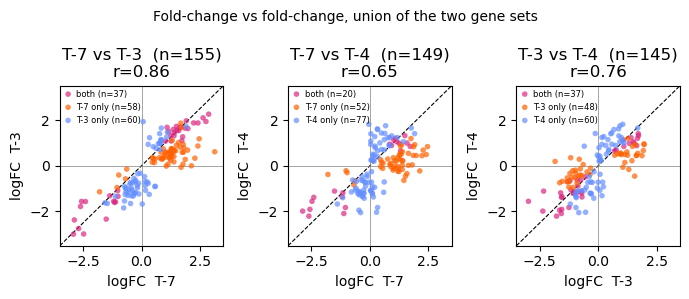

In [10]:
lfc = de_long.pivot(index="gene", columns="celltype", values="logFC")
PAIRS = [("T-7", "T-3"), ("T-7", "T-4"), ("T-3", "T-4")]
COLORS = ["#DC267F", "#FE6100", "#648FFF"]  # both, a-only, b-only

def fc_panel(ax, a, b, genes, title=None):
    d = lfc.loc[lfc.index.isin(genes), [a, b]].dropna()
    if d.empty:
        ax.set_visible(False)
        return None

    in_a, in_b = d.index.isin(members[a]), d.index.isin(members[b])
    groups = {
        "both": in_a & in_b,
        f"{a} only": in_a & ~in_b,
        f"{b} only": ~in_a & in_b,
    }
    for (label, mask), color in zip(groups.items(), COLORS):
        if mask.any():
            ax.scatter(d.loc[mask, a], d.loc[mask, b], s=16, alpha=0.7,
                       color=color, edgecolor="none", label=f"{label} (n={mask.sum()})")

    ax.plot([-3.5, 3.5], [-3.5, 3.5], "k--", lw=0.8, zorder=0)
    ax.axhline(0, color="grey", lw=0.5, zorder=0)
    ax.axvline(0, color="grey", lw=0.5, zorder=0)

    r, _ = stats.pearsonr(d[a], d[b])
    ax.set(xlim=[-3.5, 3.5], ylim=[-3.5, 3.5], xlabel=f"logFC  {a}", ylabel=f"logFC  {b}",
           title=(title or f"{a} vs {b}  (n={len(d)})") + f"\nr={r:.2f}")
    ax.legend(fontsize=6, frameon=False, loc="upper left")

    return {"a": a, "b": b, "n": len(d), "r": r}


fig, axes = plt.subplots(1, 3, figsize=(7, 3))
stats_union = [fc_panel(ax, a, b, members[a] | members[b])
               for ax, (a, b) in zip(axes, PAIRS)]

fig.suptitle("Fold-change vs fold-change, union of the two gene sets", fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/signature_comparison_foldchange_pairs_union.pdf", bbox_inches="tight")
plt.show()

## 7. ULM against SIG26

Libraries are averaged per condition and the `none_none` profile is subtracted. ULM regresses each
condition's difference profile on signed set membership; `estimate` and `pvalue` are the t and p of
that slope, so zero means no shift from `none_none`. BH is applied once across all conditions x 3
subsets.

In [11]:
# libraries averaged within a condition, then the none_none profile subtracted:
# one control-referenced difference profile per condition, conditions x genes
cond_expr = sig26_expr.groupby(sig26_meta["condition"]).mean()
sig26_delta = cond_expr.drop(index=CONTROL_LABEL) - cond_expr.loc[CONTROL_LABEL]

# ULM: each difference profile regressed on signed set membership. `estimate` and `pvalue`
# are the t and p of that slope -- the fit's own statistics, not a test between replicates.
scores, pvals = dc.mt.ulm(sig26_delta, net[["source", "target", "weight"]], tmin=0)

enrich = pd.concat([scores.stack().rename("estimate"),
                    pvals.stack().rename("pvalue")], axis=1)
enrich.index.names = ["condition", "celltype"]
enrich = enrich.reset_index()
enrich["n_libraries"] = enrich["condition"].map(sig26_meta["condition"].value_counts())
print(f"{len(sig26_meta)} libraries -> {sig26_delta.shape[0]} condition profiles x "
      f"{sig26_delta.shape[1]} genes -> {enrich['celltype'].nunique()} sets scored")

ok = enrich["pvalue"].notna()
enrich.loc[ok, "padj_global"] = multipletests(enrich.loc[ok, "pvalue"], method="fdr_bh")[1]
print(f"BH across {int(ok.sum())} tests "
      f"({enrich['condition'].nunique()} conditions x {enrich['celltype'].nunique()} sets)")

enrich.to_csv(f"{OUT_DIR}/enrichment_sig26.csv", index=False)
enrich.sort_values("padj_global").head(12).round(4)

65 libraries -> 19 condition profiles x 13181 genes -> 3 sets scored
BH across 57 tests (19 conditions x 3 sets)


,condition,celltype,estimate,pvalue,n_libraries,padj_global
56,TNF,T-7,4.9405,0.0000,6,0.0001
5,IFNG-TNF,T-7,4.7712,0.0000,3,0.0002
41,IL6-TNF,T-7,4.2833,0.0001,3,0.0011
36,IL6,T-3,4.1724,0.0001,3,0.0013
26,IL27-TNF,T-7,3.8879,0.0003,3,0.0029
12,IL21,T-3,3.9288,0.0003,3,0.0029
39,IL6-TNF,T-3,3.2134,0.0020,3,0.0161
53,TGFB-TNF,T-7,3.2077,0.0040,2,0.0287
38,IL6,T-7,2.9403,0.0049,3,0.0312
45,TGFB-IL2,T-3,3.0464,0.0070,3,0.0370


### 7.1 Condition × subset heatmap

2026-09-06 10:07:18 | [INFO] maxp pruned
2026-09-06 10:07:18 | [INFO] cmap pruned
2026-09-06 10:07:18 | [INFO] kern dropped
2026-09-06 10:07:18 | [INFO] post pruned
2026-09-06 10:07:18 | [INFO] FFTM dropped
2026-09-06 10:07:18 | [INFO] GPOS pruned
2026-09-06 10:07:18 | [INFO] GSUB pruned
2026-09-06 10:07:18 | [INFO] glyf pruned
2026-09-06 10:07:18 | [INFO] Added gid0 to subset
2026-09-06 10:07:18 | [INFO] Added first four glyphs to subset
2026-09-06 10:07:18 | [INFO] Closing glyph list over 'MATH': 48 glyphs before
2026-09-06 10:07:18 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'R', 'S', 'T', 'U', 'a', 'asterisk', 'c', 'd', 'e', 'five', 'four', 'g', 'greater', 'h', 'hyphen', 'i', 'j', 'l', 'less', 'm', 'minus', 'n', 'nonmarkingreturn', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'zero']
2026-09-06 10:07:18 | [INFO] Glyph IDs:   [0, 1, 2, 3, 13, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 31, 33, 36, 37,

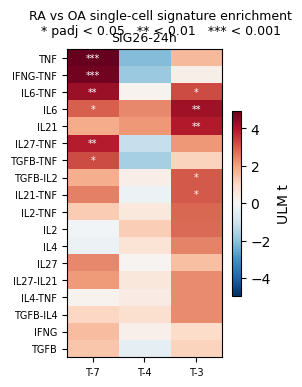

In [12]:
STAR_LEVELS = [(0.001, "***"), (0.01, "**"), (0.05, "*")]
STAR_LEGEND = "* padj < 0.05   ** < 0.01   *** < 0.001"

def stars(p):
    """Significance marker for one padj."""
    if p is None or not np.isfinite(p):
        return ""
    return next((mark for cut, mark in STAR_LEVELS if p < cut), "")

conditions_remove = ['IL4-IL21']

enrich_sub = enrich[~enrich['condition'].isin(conditions_remove)].copy()
wide = enrich_sub.pivot(index="condition", columns="celltype", values="estimate")[ORDER]
padj = enrich_sub.pivot(index="condition", columns="celltype", values="padj_global")[ORDER]
# conditions ranked by their best subset score
cond_order = wide.max(axis=1).sort_values(ascending=False).index
wide, padj = wide.loc[cond_order], padj.loc[cond_order]
vmax = np.nanmax(np.abs(wide.to_numpy()))          # symmetric colour scale around zero

fig, ax = plt.subplots(figsize=(2.5, 4))
im = ax.imshow(wide.to_numpy(), cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(wide.shape[1]), wide.columns, fontsize=7)
ax.set_yticks(range(wide.shape[0]), wide.index, fontsize=7)
ax.set_title(SIG26_RUN, fontsize=9)
for i in range(wide.shape[0]):
    for j in range(wide.shape[1]):
        ax.text(j, i, stars(padj.iat[i, j]), ha="center", va="center", fontsize=7, color="white")

fig.colorbar(im, ax=ax, shrink=0.6, label="ULM t")
fig.suptitle(f"RA vs OA single-cell signature enrichment\n{STAR_LEGEND}", fontsize=9)
plt.savefig(f"{OUT_DIR}/ulm_heatmap.pdf", bbox_inches="tight")
plt.show()

### 7.2 Per-library ULM

§7.1 averages libraries before fitting, so its p-values come from the fit rather than from
replicates. Here ULM is fitted once per library, each referenced to its own donor's mean
`none_none` profile, and subsets are compared across libraries with Welch's t-test (BH across all
tests).

In [13]:
# calculate per-donor mean none_none profile
is_ctrl = sig26_meta["condition"] == CONTROL_LABEL
ctrl_per_donor = sig26_meta.loc[is_ctrl, "donor"].value_counts()
print("control libraries per donor: "
      + ", ".join(f"{d} {ctrl_per_donor[d]}" for d in sorted(ctrl_per_donor.index)))

# calculate donor-matched deltas for every library.
donor_ref = sig26_expr[is_ctrl].groupby(sig26_meta.loc[is_ctrl, "donor"]).mean()
lib_delta = sig26_expr - donor_ref.loc[sig26_meta["donor"]].to_numpy()

# score every library's donor-matched delta against the signed gene sets.
scores_rep, pvals_rep = dc.mt.ulm(lib_delta, net[["source", "target", "weight"]], tmin=0)
enrich_rep = pd.concat([scores_rep.stack().rename("estimate"),
                        pvals_rep.stack().rename("pvalue")], axis=1)
enrich_rep.index.names = ["library", "celltype"]
enrich_rep = (enrich_rep.reset_index()
              .merge(sig26_meta[["condition", "donor"]],
                     left_on="library", right_index=True))
print(f"{len(sig26_meta)} libraries x {lib_delta.shape[1]} genes -> "
      f"{enrich_rep['celltype'].nunique()} sets scored")
enrich_rep.to_csv(f"{OUT_DIR}/ulm_enrichment_sig26_replicates.csv", index=False)

control libraries per donor: donor1 2, donor3 2, donor4 2
65 libraries x 13181 genes -> 3 sets scored


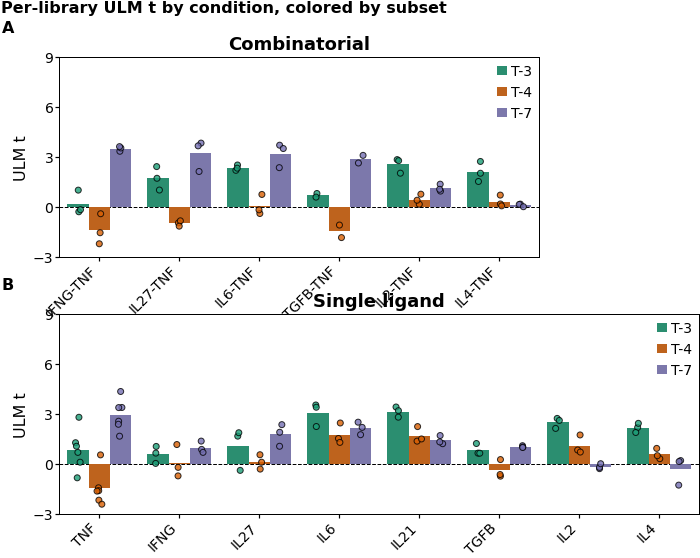

In [27]:
import logging
logging.getLogger("matplotlib.category").setLevel(logging.WARNING)

COMBO_CONDITIONS = ["IFNG-TNF", "IL27-TNF", "IL6-TNF", "TGFB-TNF", "IL2-TNF", "IL4-TNF"]
SINGLE_CONDITIONS = ["TNF", "IFNG", "IL27", "IL6", "IL21", "TGFB", "IL2", "IL4"]
REP_CONDITIONS = COMBO_CONDITIONS + SINGLE_CONDITIONS
REP_SUBSETS = ["T-3", "T-4", "T-7"]
palette = sns.color_palette(["#1B9E77FF", "#D95F02FF", "#7570B3FF"])

d = enrich_rep[enrich_rep["condition"].isin(REP_CONDITIONS)
               & enrich_rep["celltype"].isin(REP_SUBSETS)].copy()
d["celltype"] = pd.Categorical(d["celltype"], categories=REP_SUBSETS, ordered=True)

mp_cond = cns.multipanel(max_width=500,
                         title="Per-library ULM t by condition, colored by subset",
                         title_fontweight="bold", loc="left")

for label, (name, order) in zip("AB", [("Combinatorial", COMBO_CONDITIONS),
                                        ("Single ligand", SINGLE_CONDITIONS)]):
    sub = d[d["condition"].isin(order)]
    ax = mp_cond.panel(label, 40 * len(order), 100)
    cns.barplot(sub, x="condition", y="estimate", order=order,
               hue="celltype", hue_order=REP_SUBSETS, palette=palette, ax=ax)
    cns.stripplot(sub, x="condition", y="estimate", order=order,
                 hue="celltype", hue_order=REP_SUBSETS, palette=palette,
                 size=3, showmedian=False, alpha=0.8, linewidth=0.5,
                 edgecolor="black", dodge=True, jitter=True, ax=ax, legend=False)
    ax.axhline(0, color="black", lw=0.5, zorder=0, linestyle='--')
    ax.set_title(name, fontsize=9)
    ax.set(xlabel="", ylabel="ULM t", ylim=[-3, 9], yticks=[-3, 0, 3, 6, 9])
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    for spine in ax.spines.values():
        spine.set_visible(True)

cns.savefig(f"{OUT_DIR}/ulm_replicates_barplot_by_condition.pdf")

In [16]:
rows = []
for cond in REP_CONDITIONS:
    sub = d[d["condition"] == cond]
    for g1, g2 in combinations(REP_SUBSETS, 2):
        x1 = sub.loc[sub["celltype"] == g1, "estimate"]
        x2 = sub.loc[sub["celltype"] == g2, "estimate"]
        t_stat, pval = stats.ttest_ind(x1, x2, equal_var=False)
        rows.append({
            "condition": cond,
            "group1": g1,
            "group2": g2,
            "n1": x1.size,
            "n2": x2.size,
            "mean1": x1.mean(),
            "mean2": x2.mean(),
            "t_stat": t_stat,
            "pval": pval,
        })

pairwise_ttests = pd.DataFrame(rows)

# FDR correction (Benjamini-Hochberg) across all pairwise tests
_, qvals, _, _ = multipletests(pairwise_ttests["pval"], method="fdr_bh")
pairwise_ttests["qval"] = qvals
pairwise_ttests["significant_fdr"] = pairwise_ttests["qval"] < 0.1

pairwise_ttests = pairwise_ttests.round(
    {"mean1": 3, "mean2": 3, "t_stat": 3, "pval": 4, "qval": 4}
)
display(pairwise_ttests.query('group2 == "T-7"'))

,condition,group1,group2,n1,n2,mean1,mean2,t_stat,pval,qval,significant_fdr
1,IFNG-TNF,T-3,T-7,3,3,0.218,3.533,-7.865,0.0126,0.0469,True
2,IFNG-TNF,T-4,T-7,3,3,-1.355,3.533,-9.178,0.0100,0.0467,True
4,IL27-TNF,T-3,T-7,3,3,1.752,3.241,-2.198,0.0983,0.1376,False
5,IL27-TNF,T-4,T-7,3,3,-0.948,3.241,-7.612,0.0143,0.0469,True
7,IL6-TNF,T-3,T-7,3,3,2.380,3.222,-1.959,0.1777,0.2333,False
8,IL6-TNF,T-4,T-7,3,3,0.094,3.222,-5.721,0.0051,0.0351,True
10,TGFB-TNF,T-3,T-7,2,2,0.732,2.899,-8.544,0.0337,0.0643,True
11,TGFB-TNF,T-4,T-7,2,2,-1.429,2.899,-9.828,0.0184,0.0469,True
13,IL2-TNF,T-3,T-7,3,3,2.581,1.159,4.911,0.0181,0.0469,True
14,IL2-TNF,T-4,T-7,3,3,0.477,1.159,-3.172,0.0392,0.0715,True


In [169]:
# reset plotting parameters from cnsplots
plt.rcdefaults()
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

## 8. GSEA against the SIG26 rankings

`gseapy.prerank` (fgsea multilevel p-values), one run per condition, down SIG26's per-condition
DESeq2 `stat`. GSEA ignores sign, so each signed set is split into an up-set and a down-set.

In [159]:
# unsigned directional sets -- GSEA reads membership, not the +-1 weights the ULM uses
gsea_sets = {f"{s}_{'up' if w > 0 else 'dn'}": sorted(g["target"])
             for (s, w), g in net.groupby(["source", "weight"])}
GSEA_SETS = [f"{ct}_{d}" for ct in ORDER for d in ("up", "dn")]
print("gene sets: " + ", ".join(f"{s} {len(gsea_sets[s])}" for s in GSEA_SETS))

# conditions x genes ranking statistic, from SIG26's per-condition DESeq2 results
r = pd.read_csv(f"{SIG26_DEG}/res_conditions_{SIG26_RUN}.csv").dropna(subset=["stat", "gene"])
# duplicate symbols collapsed to the row with the largest |stat|
r = (r.assign(abs_stat=r["stat"].abs())
     .sort_values("abs_stat", ascending=False)
     .drop_duplicates(["condition", "gene"]))
gsea_ranks = (r.pivot(index="condition", columns="gene", values="stat")
              .dropna(axis=1, how="any"))

cov = {s: np.mean([g in gsea_ranks.columns for g in gsea_sets[s]]) for s in GSEA_SETS}
print(f"{SIG26_RUN} ({GSEA_RANK_LABEL}): {gsea_ranks.shape[0]} conditions x "
      f"{gsea_ranks.shape[1]} genes | set coverage "
      + ", ".join(f"{k} {v:.2f}" for k, v in cov.items()))

res, pre_runs = [], {}
for cond in gsea_ranks.index:
    pre = gp.prerank(rnk=gsea_ranks.loc[cond].sort_values(ascending=False),
                     gene_sets=gsea_sets, permutation_num=GSEA_PERM,
                     min_size=GSEA_MIN_SIZE, max_size=GSEA_MAX_SIZE,
                     threads=GSEA_THREADS, seed=GSEA_SEED, outdir=None,
                     verbose=False, no_plot=True,
                     method="multilevel")
    res.append(pre.res2d.assign(condition=cond))
    pre_runs[cond] = pre.results

gsea = (pd.concat(res, ignore_index=True)
        .rename(columns={"Term": "gene_set", "ES": "es", "NES": "nes",
                         "NOM p-val": "pvalue", "FDR q-val": "fdr_gseapy",
                         "Tag %": "tag_pct", "Lead_genes": "leading_edge"}))
for c in ("es", "nes", "pvalue", "fdr_gseapy"):
    gsea[c] = pd.to_numeric(gsea[c])
gsea["celltype"] = gsea["gene_set"].str.split("_").str[0]
gsea["direction"] = gsea["gene_set"].str.split("_").str[1]

# a set can be dropped silently if too few of its genes are in the ranking -- say so
scored = gsea.groupby("condition")["gene_set"].nunique()
if (scored < len(GSEA_SETS)).any():
    print("\nsets dropped by min_size/max_size:")
    print(scored[scored < len(GSEA_SETS)].to_string())

ok = gsea["pvalue"].notna()
gsea.loc[ok, "padj_global"] = multipletests(gsea.loc[ok, "pvalue"], method="fdr_bh")[1]
print(f"\nBH across {int(ok.sum())} tests "
      f"({gsea['condition'].nunique()} conditions x {gsea['gene_set'].nunique()} sets)")

COLS = ["condition", "gene_set", "celltype", "direction", "es", "nes",
        "pvalue", "padj_global", "fdr_gseapy", "tag_pct", "leading_edge"]
gsea[COLS].to_csv(f"{OUT_DIR}/gsea_sig26.csv", index=False)
display(gsea.nlargest(12, "nes")[["condition", "gene_set", "es", "nes",
                                  "pvalue", "padj_global", "tag_pct"]])

gene sets: T-7_up 77, T-7_dn 23, T-4_up 47, T-4_dn 53, T-3_up 41, T-3_dn 59
SIG26-24h (DESeq2 stat): 19 conditions x 13181 genes | set coverage T-7_up 0.92, T-7_dn 0.61, T-4_up 0.96, T-4_dn 0.92, T-3_up 0.85, T-3_dn 0.88

BH across 114 tests (19 conditions x 6 sets)


,condition,gene_set,es,nes,pvalue,padj_global,tag_pct
6,IFNG-TNF,T-7_up,0.633257,2.288954,7.545412e-08,0.000009,27/71
108,TNF,T-7_up,0.595670,2.168849,2.557602e-06,0.000097,24/71
72,IL6,T-3_up,0.671865,2.168334,1.808258e-05,0.000344,11/35
48,IL27-TNF,T-7_up,0.584973,2.040785,4.695248e-06,0.000107,31/71
25,IL21,T-3_up,0.635937,2.024223,1.320616e-04,0.000886,9/35
78,IL6-TNF,T-7_up,0.552436,1.959575,5.275202e-05,0.000547,26/71
0,IFNG,T-7_up,0.497499,1.931919,2.041766e-04,0.001164,27/71
79,IL6-TNF,T-3_up,0.606142,1.888417,1.046190e-03,0.004417,8/35
7,IFNG-TNF,T-4_dn,0.558500,1.881404,5.750113e-04,0.002622,15/49
109,TNF,T-4_dn,0.553700,1.875410,1.103663e-03,0.004493,15/49


### 8.1 NES lollipops, up-sets and down-sets

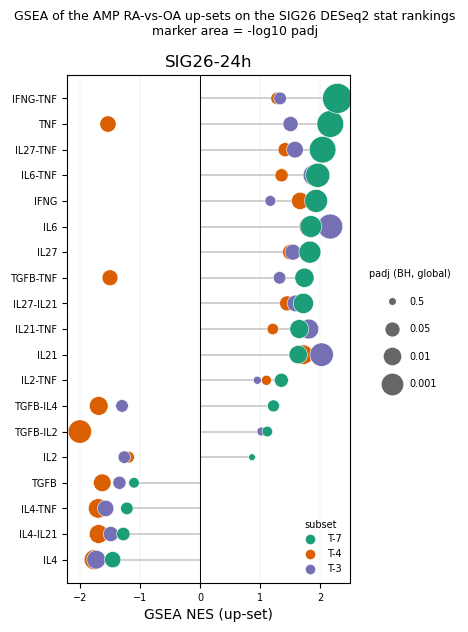

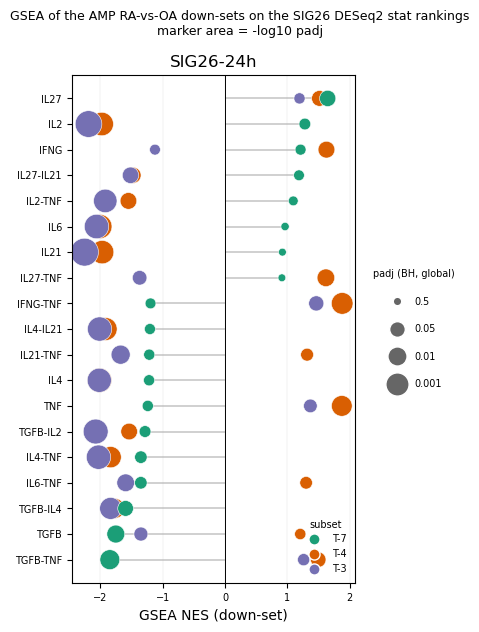

In [170]:
MARKER_MIN, MARKER_MAX = 10, 100
COLORS = dict(zip(ORDER, sns.color_palette("Dark2", 3)))
DIRECTION_LABEL = {"up": "up-set", "dn": "down-set"}

def marker_size(padj):
    """Point area from -log10(padj), bounded to a fixed scale."""
    # tiny numerical floor only to guard against log10(0); not a GSEA permutation floor
    v = -np.log10(np.clip(np.asarray(padj, dtype=float), 1e-300, 1.0))
    return MARKER_MIN + (MARKER_MAX - MARKER_MIN) * v

def nes_lollipop(direction):
    d_set = gsea[gsea["direction"] == direction]
    nes_w = d_set.pivot(index="condition", columns="celltype", values="nes")[ORDER]
    padj_w = d_set.pivot(index="condition", columns="celltype", values="padj_global")[ORDER]
    gsea_order = nes_w["T-7"].sort_values().index      # largest ends up at the top

    fig, ax = plt.subplots(figsize=(4.8, 6.4))
    n, q = nes_w.loc[gsea_order], padj_w.loc[gsea_order]
    y = np.arange(len(n))
    ax.hlines(y, 0, n["T-7"], color="#c8c8c8", lw=1.2, zorder=0)
    for ct in ORDER:
        ax.scatter(n[ct], y, s=marker_size(q[ct]), color=COLORS[ct],
                   edgecolor="white", linewidth=0.4, zorder=3 if ct == "T-7" else 2)
    ax.axvline(0, color="k", lw=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(n.index, fontsize=7)
    ax.set(xlabel=f"GSEA NES ({DIRECTION_LABEL[direction]})", title=SIG26_RUN)
    ax.grid(axis="x", lw=0.3, alpha=0.4)
    ax.tick_params(labelsize=7)

    subset_h = [Line2D([], [], marker="o", linestyle="none", markerfacecolor=COLORS[ct],
                      markeredgecolor="white", markersize=8, label=ct) for ct in ORDER]
    size_keys = [0.5, 0.05, 0.01, 0.001]
    size_h = [Line2D([], [], marker="o", linestyle="none", markerfacecolor="#666666",
                     markeredgecolor="white",
                     markersize=np.sqrt(marker_size([q])[0]),
                     label=f"{q:g}") for q in size_keys]
    ax.add_artist(ax.legend(handles=subset_h, title="subset", fontsize=7,
                            title_fontsize=7, frameon=False, loc="lower right"))
    # outside the axes: at this marker range an inset size legend lands on the data
    ax.legend(handles=size_h, title="padj (BH, global)", fontsize=7, title_fontsize=7,
                frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5),
                labelspacing=1.8, borderpad=0.8)
    fig.suptitle(f"GSEA of the AMP RA-vs-OA {DIRECTION_LABEL[direction]}s on the SIG26 "
                 f"{GSEA_RANK_LABEL} rankings\nmarker area = -log10 padj", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/gsea_nes_lollipop_{direction}.pdf", bbox_inches="tight")
    plt.show()

for direction in ("up", "dn"):
    nes_lollipop(direction)

### 8.2 T-7 vs T-3 NES across conditions, up-sets and down-sets

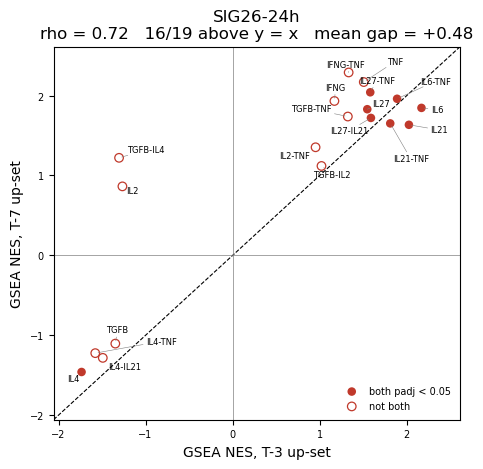

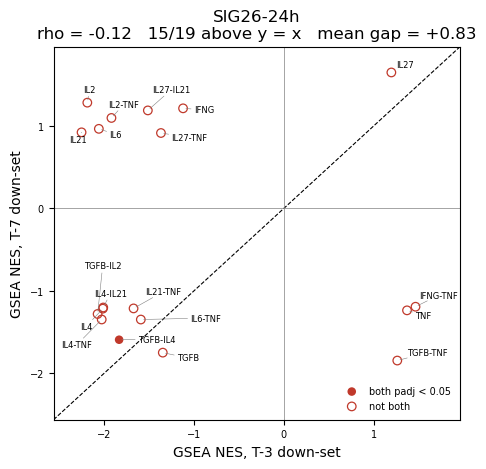

In [171]:
def t7_vs_t3_scatter(direction):
    d_set = gsea[gsea["direction"] == direction]
    nes_p = d_set.pivot_table(index="condition", columns="celltype", values="nes")
    padj_p = d_set.pivot_table(index="condition", columns="celltype", values="padj_global")
    lim = np.array([nes_p[["T-7", "T-3"]].to_numpy().min(),
                    nes_p[["T-7", "T-3"]].to_numpy().max()])
    lim = lim + np.array([-1, 1]) * 0.08 * (lim[1] - lim[0])

    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    d, q = nes_p, padj_p
    sig = (q["T-7"] < 0.05) & (q["T-3"] < 0.05)
    ax.scatter(d.loc[sig, "T-3"], d.loc[sig, "T-7"], s=38, color="#c0392b",
               edgecolor="none", label="both padj < 0.05")
    ax.scatter(d.loc[~sig, "T-3"], d.loc[~sig, "T-7"], s=38, facecolor="none",
               edgecolor="#c0392b", linewidth=0.9, label="not both")
    ax.plot(lim, lim, "k--", lw=0.8, zorder=0)
    ax.axhline(0, color="grey", lw=0.5, zorder=0)
    ax.axvline(0, color="grey", lw=0.5, zorder=0)
    gap = d["T-7"] - d["T-3"]
    rho = d[["T-3", "T-7"]].corr(method="spearman").iat[0, 1]
    ax.set(xlim=lim, ylim=lim, xlabel=f"GSEA NES, T-3 {DIRECTION_LABEL[direction]}",
           ylabel=f"GSEA NES, T-7 {DIRECTION_LABEL[direction]}",
           title=f"{SIG26_RUN}\nrho = {rho:.2f}   {int((gap > 0).sum())}/{len(gap)} above "
                 f"y = x   mean gap = {gap.mean():+.2f}")
    texts = [ax.text(d.at[c, "T-3"], d.at[c, "T-7"], c, fontsize=6) for c in d.index]
    # the points bunch in the top-right corner, so the defaults leave labels overlapping
    adjust_text(texts, ax=ax, expand=(1.4, 1.7), force_text=(0.5, 0.8),
                force_static=(0.3, 0.5),
                arrowprops=dict(arrowstyle="-", lw=0.4, color="grey"))
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, frameon=False, loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/gsea_t7_vs_t3_nes_{direction}.pdf", bbox_inches="tight")
    plt.show()

for direction in ("up", "dn"):
    t7_vs_t3_scatter(direction)

### 8.3 Running enrichment curves

One column per selected condition, one curve per subset; up-sets first, then down-sets. Down-sets
are the smaller half of each signed set, so flat curves there partly reflect set size.

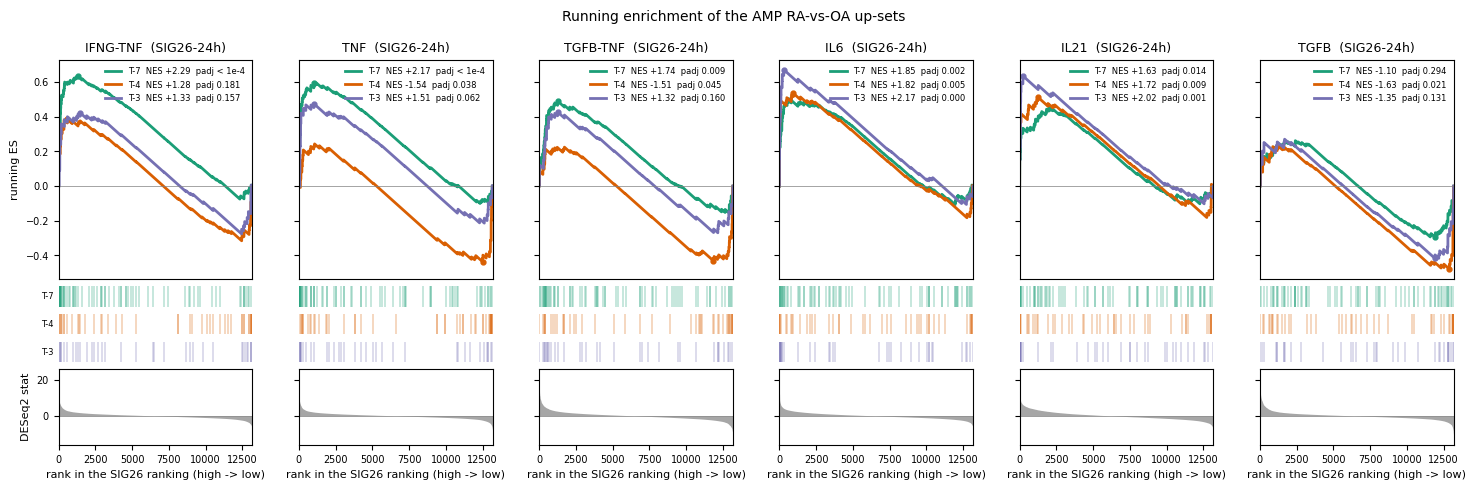

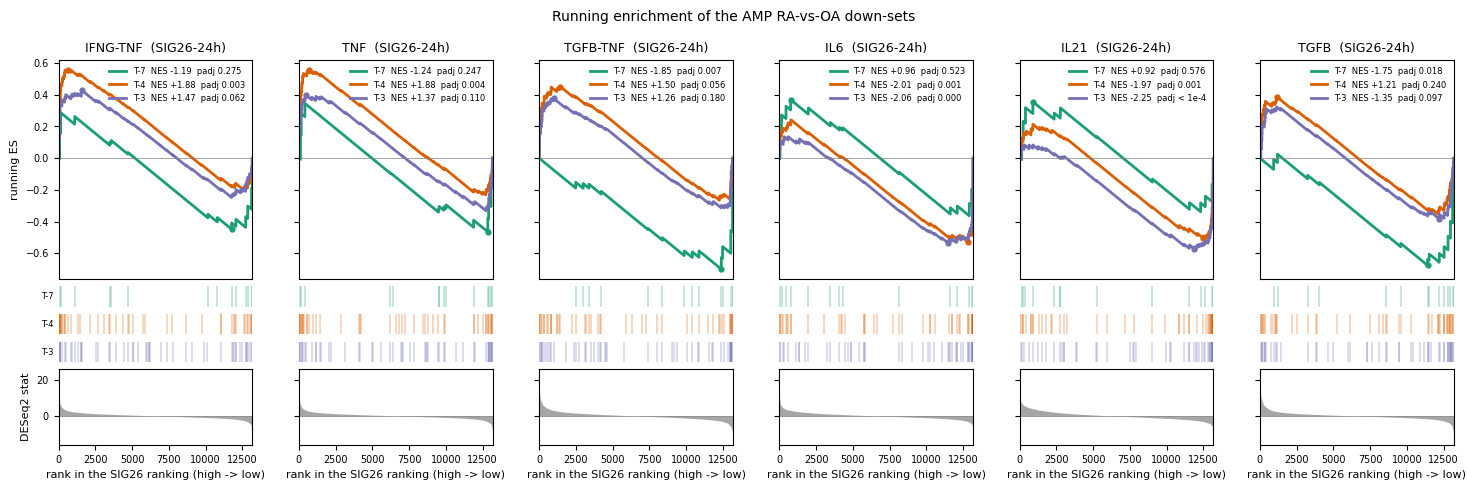

In [175]:
RES_CONDITIONS = ["IFNG-TNF", "TNF", "TGFB-TNF", "IL6", "IL21", "TGFB"]

lookup = gsea.set_index(["condition", "gene_set"])

def running_es(direction):
    es_ax = metric_ax = None            # first column's axes, shared by the others
    fig = plt.figure(figsize=(3 * len(RES_CONDITIONS), 5))
    grid = fig.add_gridspec(len(ORDER) + 2, len(RES_CONDITIONS),
                            height_ratios=[3.2] + [0.3] * len(ORDER) + [1.1],
                            hspace=0.1, wspace=0.24)

    for j, cond in enumerate(RES_CONDITIONS):
        results = pre_runs[cond]
        rank = gsea_ranks.loc[cond].sort_values(ascending=False)
        n = rank.size

        # y shared across conditions: the panels are only comparable on one ES scale
        ax = fig.add_subplot(grid[0, j], sharey=es_ax)
        es_ax = es_ax or ax
        for ct in ORDER:
            curve = np.asarray(results[f"{ct}_{direction}"]["RES"])
            row = lookup.loc[(cond, f"{ct}_{direction}")]
            q = row["padj_global"]
            ax.plot(curve, lw=2, color=COLORS[ct],
                    label=f"{ct}  NES {row['nes']:+.2f}  "
                          f"padj {'< 1e-4' if q < 1e-4 else format(q, '.3f')}")
            peak = int(np.argmax(np.abs(curve)))          # the rank where the ES is taken
            ax.plot([peak], [curve[peak]], marker="o", ms=3.5, color=COLORS[ct])
        ax.axhline(0, color="grey", lw=0.5)
        ax.set(xlim=(0, n), xticks=[])
        ax.set_title(f"{cond}  ({SIG26_RUN})", fontsize=9)
        ax.legend(fontsize=6, frameon=False, loc="upper right")
        ax.tick_params(labelsize=7)
        if j == 0:
            ax.set_ylabel("running ES", fontsize=8)
        else:
            ax.tick_params(labelleft=False)

        for k, ct in enumerate(ORDER):        # set membership along the same x axis
            axh = fig.add_subplot(grid[1 + k, j])
            axh.vlines(np.asarray(results[f"{ct}_{direction}"]["hits"]), 0, 1, lw=0.35, color=COLORS[ct])
            axh.set(xlim=(0, n), ylim=(0, 1), xticks=[], yticks=[])
            for side in axh.spines.values():
                side.set_visible(False)
            if j == 0:
                axh.set_ylabel(ct, fontsize=6, rotation=0, ha="right", va="center")

        axm = fig.add_subplot(grid[-1, j], sharey=metric_ax)
        metric_ax = metric_ax or axm
        axm.fill_between(np.arange(n), rank.to_numpy(), color="#a6a6a6", lw=0)
        axm.axhline(0, color="grey", lw=0.5)
        axm.set(xlim=(0, n))
        axm.set_xlabel("rank in the SIG26 ranking (high -> low)", fontsize=8)
        axm.tick_params(labelsize=7)
        if j == 0:
            axm.set_ylabel(GSEA_RANK_LABEL, fontsize=8)
        else:
            axm.tick_params(labelleft=False)

    fig.suptitle(f"Running enrichment of the AMP RA-vs-OA {DIRECTION_LABEL[direction]}s", fontsize=10)
    plt.savefig(f"{OUT_DIR}/gsea_running_es_{direction}.pdf", bbox_inches="tight")
    plt.show()

for direction in ("up", "dn"):
    running_es(direction)